# Series de Tiempo II

In [183]:
import warnings 
warnings.filterwarnings('ignore')

In [184]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import os

In [185]:
import chart_studio.plotly as py
from plotly.offline import init_notebook_mode, iplot
init_notebook_mode(connected=True)
import plotly.graph_objs as go
import plotly.figure_factory as ff
import statsmodels.api as sm
from numpy.random import normal, seed
from scipy.stats import norm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import math
from sklearn.metrics import mean_absolute_error

from statsmodels.tsa.arima_model import ARMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.arima_model import ARIMA

# Importación de datos de stocks del ejercicio anterior

In [186]:
df_apple = pd.read_csv('./AAPL.csv',index_col='Date',parse_dates=['Date'])

### Exploratory Data Analysis: head

In [187]:
df_apple.head(10)

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2019-05-31,43.181805,43.613062,42.877969,42.897572,108174400,0.0,0.0
2019-06-03,43.027439,43.595909,41.721424,42.463867,161584400,0.0,0.0
2019-06-04,42.988224,44.063910,42.762796,44.017353,123872000,0.0,0.0
2019-06-05,45.154295,45.328268,44.384898,44.727940,119093600,0.0,0.0
2019-06-06,44.860258,45.445882,44.632378,45.384624,90105200,0.0,0.0
2019-06-07,45.700720,47.026338,45.519399,46.592632,122737600,0.0,0.0
2019-06-10,46.999386,47.871695,46.952829,47.188061,104883600,0.0,0.0
2019-06-11,47.746726,48.026062,47.437989,47.734474,107731600,0.0,0.0
2019-06-12,47.523745,48.018709,47.386528,47.582554,73012800,0.0,0.0


In [188]:
df_tesla.head(10)

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2019-05-31,37.020000,37.984001,36.820000,37.032001,52033500,0,0.0
2019-06-03,37.102001,37.335999,35.397999,35.793999,65322000,0,0.0
2019-06-04,36.220001,38.796001,35.922001,38.720001,69037500,0,0.0
2019-06-05,39.736000,40.256001,38.369999,39.318001,67554000,0,0.0
2019-06-06,40.888000,42.200001,40.360001,41.189999,101211000,0,0.0
2019-06-07,41.000000,42.167999,40.700001,40.900002,80017500,0,0.0
2019-06-10,42.049999,43.388000,41.801998,42.576000,52925000,0,0.0
2019-06-11,43.827999,44.180000,42.700001,43.419998,58267500,0,0.0
2019-06-12,44.590000,44.675999,41.799999,41.852001,75987500,0,0.0


# Generación de modelo de series de tiempo aplicado a los datos importados usando el modelo de Reversión a la Media, y además el de Movimiento Browniano

In [189]:
def mod_vasicek(r0,K,theta,sigma,T=1,N=10,seed=777):
    np.random.seed(seed)
    dt = T/float(N)
    rates = [r0]
    for i in range(N):
        dr = K*(theta-rates[-1])*dt + sigma*np.random.normal()
        rates.append(rates[-1]+dr)
    return range(N+1), rates

In [190]:
import numpy as np

r0 = 0.1875
K = 0.2
theta = df_apple['Close'].mean()
sigma = df_apple['Close'].std()*0.05
T = 10
seed = np.random.randint(100,900)
N = 1000
x , y = mod_vasicek(r0,K,theta,sigma,T,N,seed) 

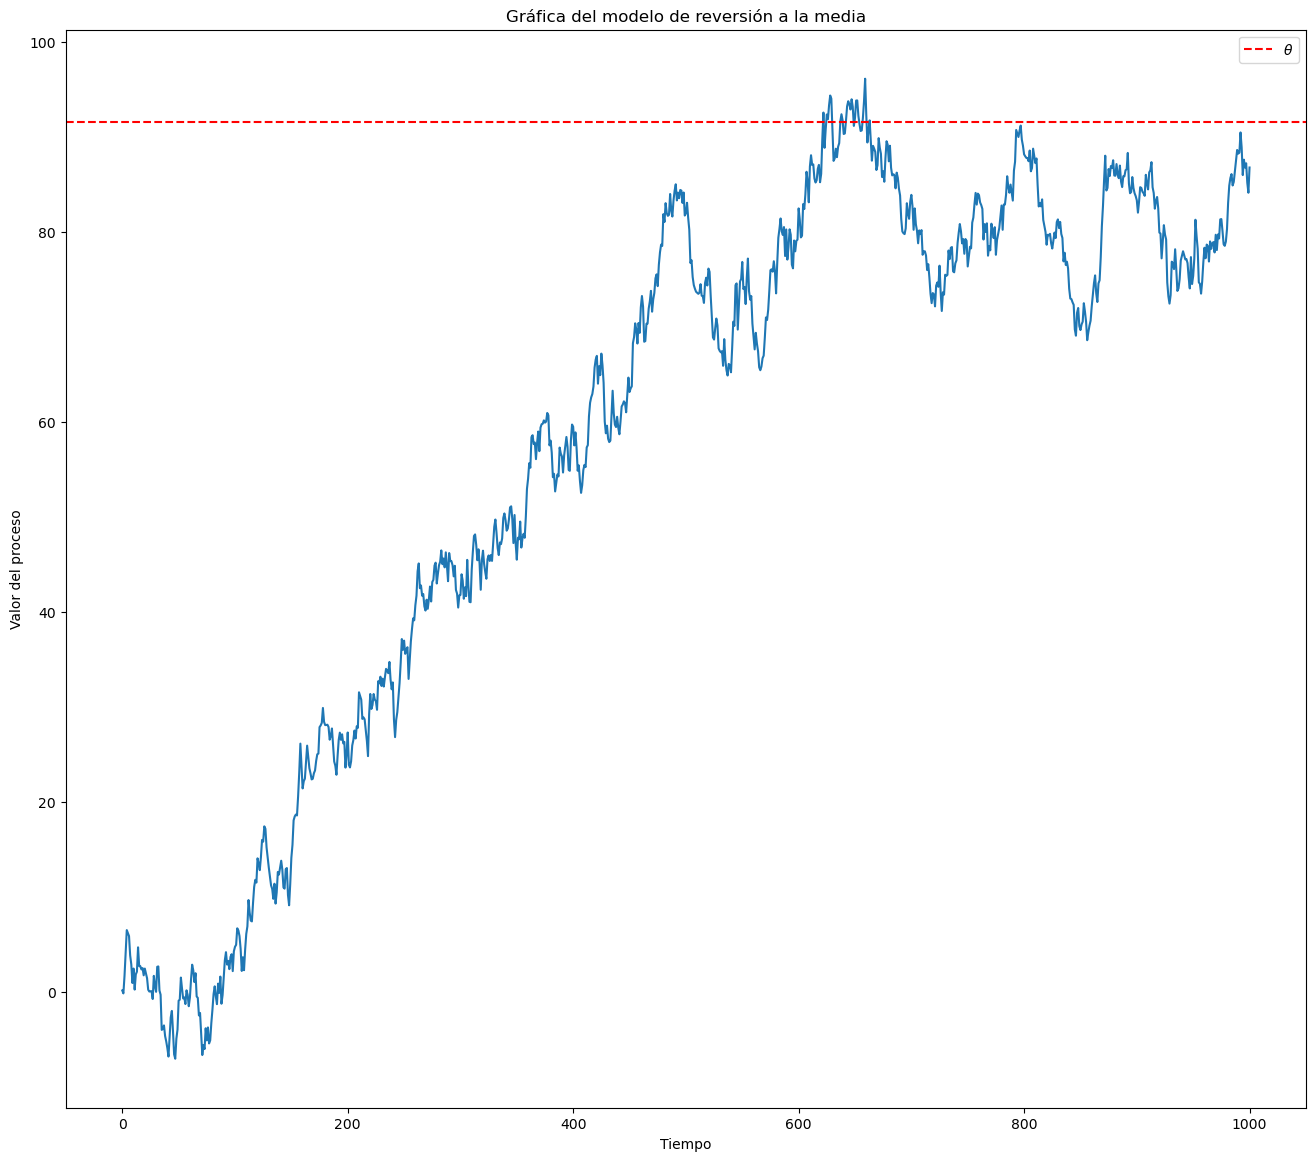

In [191]:
import matplotlib.pyplot as plt

plt.plot(x, y)
plt.title('Gráfica del modelo de reversión a la media')
plt.axhline(y=theta, color='red', linestyle='--', label=r'$\theta$')
plt.xlabel('Tiempo')
plt.ylabel('Valor del proceso')
plt.legend()
plt.show()

# Modelo autorregresivo y de moving average

In [192]:
from statsmodels.tsa.arima.model import ARIMA

serie = df_apple['Close']
model = ARIMA(serie, order=(1, 0, 0))  # AR(1)
result = model.fit()

print(result.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  526
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1147.858
Date:                Tue, 14 Jul 2026   AIC                           2301.717
Time:                        19:25:21   BIC                           2314.513
Sample:                             0   HQIC                          2306.727
                                - 526                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         91.5647     31.593      2.898      0.004      29.643     153.486
ar.L1          0.9986      0.003    336.371      0.000       0.993       1.004
sigma2         4.5511      0.172     26.508      0.0

In [193]:
print('miu = {} ,phi = {}'.format(result.params[0],result.params[1]))
print(result.summary())

miu = 91.56466761619478 ,phi = 0.9986427768354966
                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  526
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1147.858
Date:                Tue, 14 Jul 2026   AIC                           2301.717
Time:                        19:25:21   BIC                           2314.513
Sample:                             0   HQIC                          2306.727
                                - 526                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         91.5647     31.593      2.898      0.004      29.643     153.486
ar.L1          0.9986      0.003    336.371      0.000       0.993       1.004
si

In [194]:
df_apple.shape

(526, 7)

# Ejercicio de predicción de modelos

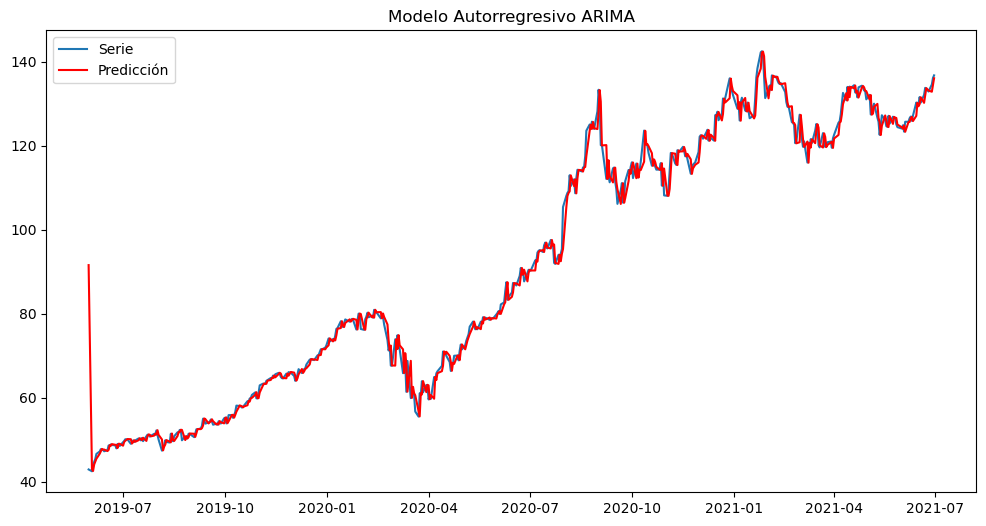

In [195]:
import matplotlib.pyplot as plt

# Predicciones
pred = result.predict(start=0, end=len(serie)-1)

# Gráfica
plt.figure(figsize=(12,6))
plt.plot(serie, label='Serie')
plt.plot(pred, color='red', label='Predicción')
plt.legend()
plt.title('Modelo Autorregresivo ARIMA')
plt.show()

### RMSE

In [196]:
from sklearn.metrics import mean_squared_error

rmse_arima = np.sqrt(mean_squared_error(serie, pred))

print("RMSE ARIMA =", rmse_arima)

RMSE ARIMA = 3.0069430608269756


### Intervalo de confianza

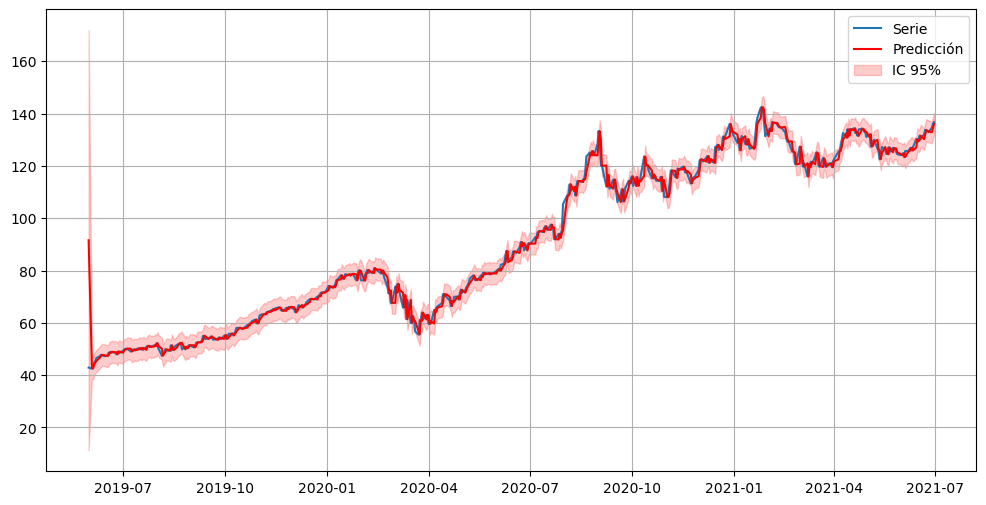

In [197]:
import numpy as np
import matplotlib.pyplot as plt

start = 0
end = len(serie) - 1

pred = result.get_prediction(start=start, end=end, dynamic=False)

pred_mean = pred.predicted_mean
conf_int = pred.conf_int()

plt.figure(figsize=(12,6))

plt.plot(serie.index, serie, label='Serie')
plt.plot(pred_mean.index, pred_mean, color='red', label='Predicción')

plt.fill_between(
    pred_mean.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color='red',
    alpha=0.2,
    label='IC 95%'
)

plt.legend()
plt.grid(True)
plt.show()

### RMSE

In [198]:
import math
from sklearn.metrics import mean_squared_error
rmse = math.sqrt(mean_squared_error(serie, result.predict(start=start,end=end)))
print('RMSE ={}'.format(rmse))

RMSE =3.0069430608269756


In [199]:
df_apple['Close'].diff().iloc[1:].values

array([-4.33704376e-01,  1.55348587e+00,  7.10586548e-01,  6.56684875e-01,
        1.20800781e+00,  5.95428467e-01,  5.46413422e-01, -1.51920319e-01,
       -9.79614258e-03, -3.45493317e-01,  2.81780243e-01,  1.11735153e+00,
       -1.42127991e-01,  3.89606476e-01, -1.66625977e-01, -4.90036011e-02,
       -7.37541199e-01,  1.03647995e+00, -1.47056580e-02, -4.45957184e-01,
        8.89461517e-01,  2.89138794e-01,  4.11655426e-01, -4.41093445e-02,
       -1.03158188e+00,  2.98946381e-01,  4.87598419e-01, -3.62632751e-01,
        3.79787445e-01,  4.68021393e-01, -1.73980713e-01, -2.81780243e-01,
        5.66017151e-01, -7.52246857e-01,  1.13449097e+00,  3.96953583e-01,
       -4.16603088e-02, -4.04293060e-01,  1.76418304e-01,  4.75353241e-01,
       -2.20516205e-01,  1.04382324e+00, -1.12959290e+00, -1.08057785e+00,
       -2.61692810e+00,  8.96804810e-01,  4.99866486e-01,  1.07568359e+00,
       -4.10755157e-01, -1.25442505e-01,  2.08822250e+00, -1.52988815e+00,
       -2.48420715e-01,  

### Modelo de Media Móvil de orden 2 (MA(2))

In [200]:
model = ARIMA(serie, order=(0,0,2))
result = model.fit()

In [201]:
print('miu = {} ,phi = {}'.format(result.params[0],result.params[1]))
print(result.summary())


miu = 91.65834010086522 ,phi = 1.5132469915250941
                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  526
Model:                 ARIMA(0, 0, 2)   Log Likelihood               -1958.706
Date:                Tue, 14 Jul 2026   AIC                           3925.412
Time:                        19:25:22   BIC                           3942.473
Sample:                             0   HQIC                          3932.092
                                - 526                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         91.6583      1.478     62.024      0.000      88.762      94.555
ma.L1          1.5132      0.024     64.276      0.000       1.467       1.559
ma

In [202]:
df_apple['Close'].diff().iloc[1:].values

array([-4.33704376e-01,  1.55348587e+00,  7.10586548e-01,  6.56684875e-01,
        1.20800781e+00,  5.95428467e-01,  5.46413422e-01, -1.51920319e-01,
       -9.79614258e-03, -3.45493317e-01,  2.81780243e-01,  1.11735153e+00,
       -1.42127991e-01,  3.89606476e-01, -1.66625977e-01, -4.90036011e-02,
       -7.37541199e-01,  1.03647995e+00, -1.47056580e-02, -4.45957184e-01,
        8.89461517e-01,  2.89138794e-01,  4.11655426e-01, -4.41093445e-02,
       -1.03158188e+00,  2.98946381e-01,  4.87598419e-01, -3.62632751e-01,
        3.79787445e-01,  4.68021393e-01, -1.73980713e-01, -2.81780243e-01,
        5.66017151e-01, -7.52246857e-01,  1.13449097e+00,  3.96953583e-01,
       -4.16603088e-02, -4.04293060e-01,  1.76418304e-01,  4.75353241e-01,
       -2.20516205e-01,  1.04382324e+00, -1.12959290e+00, -1.08057785e+00,
       -2.61692810e+00,  8.96804810e-01,  4.99866486e-01,  1.07568359e+00,
       -4.10755157e-01, -1.25442505e-01,  2.08822250e+00, -1.52988815e+00,
       -2.48420715e-01,  

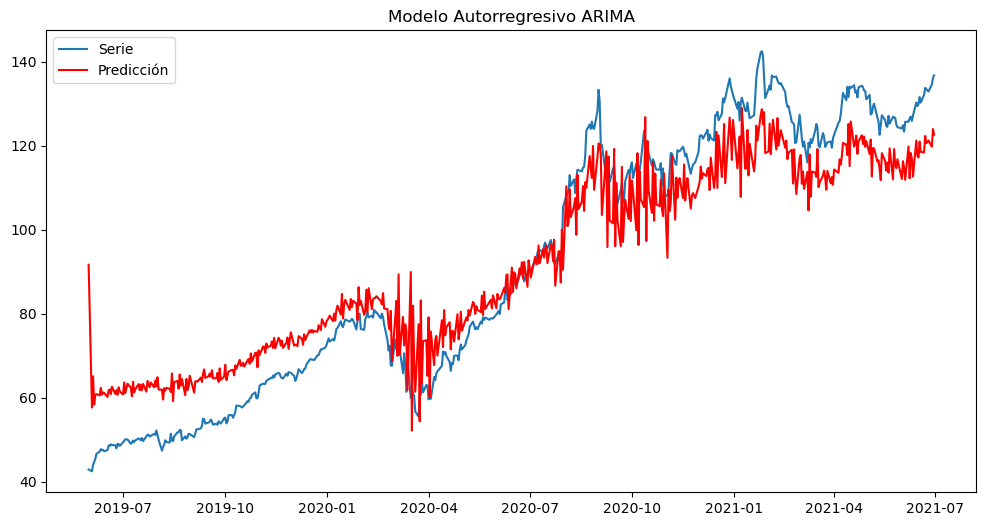

In [203]:
import matplotlib.pyplot as plt

# Predicciones
pred = result.predict(start=0, end=len(serie)-1)

# Gráfica
plt.figure(figsize=(12,6))
plt.plot(serie, label='Serie')
plt.plot(pred, color='red', label='Predicción')
plt.legend()
plt.title('Modelo Autorregresivo ARIMA')
plt.show()

# Visualización simple de Series de Tiempo

<Axes: xlabel='Date'>

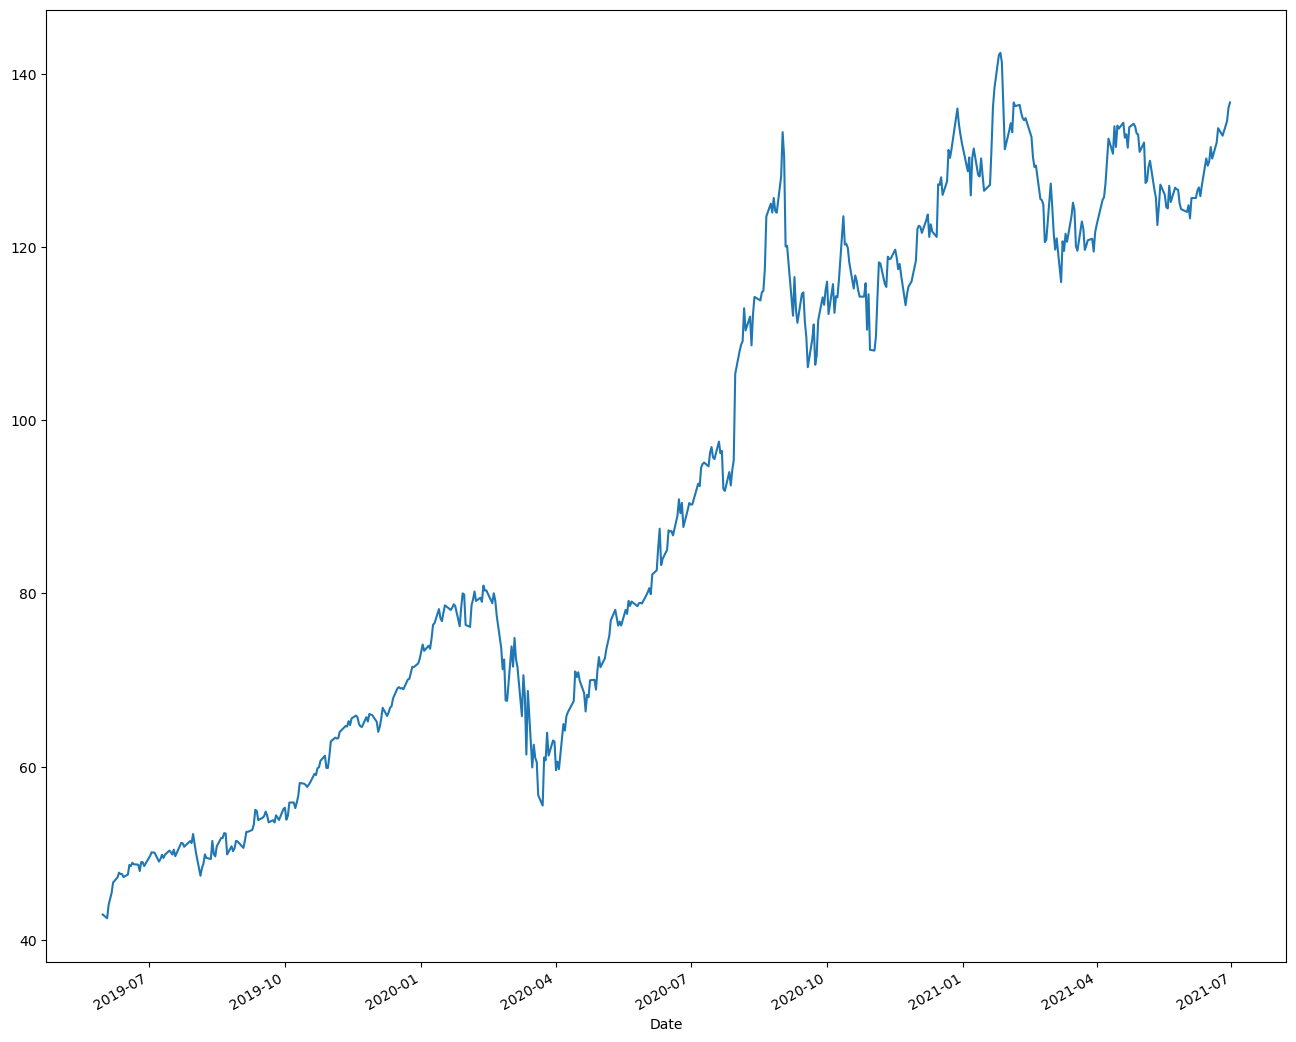

In [204]:
df_apple['Close'].plot()